In [4]:
# Check GPU
import torch
print(torch.cuda.is_available())  # must be True

# Install extras
!pip install -q timm opencv-python-headless matplotlib scikit-learn

True


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [11]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
import os

BASE = "/kaggle/input/chest-xray-pneumonia/chest_xray"

# Quick check — should show NORMAL and PNEUMONIA
print(os.listdir(os.path.join(BASE, "train")))

# Load train and test with a placeholder transform first
plain_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_full = ImageFolder(os.path.join(BASE, "train"), transform=plain_tf)
test_ds    = ImageFolder(os.path.join(BASE, "test"),  transform=plain_tf)

print(f"Train: {len(train_full)}  Test: {len(test_ds)}")
print("Class map:", train_full.class_to_idx)  # {NORMAL:0, PNEUMONIA:1}

['PNEUMONIA', 'NORMAL']
Train: 5216  Test: 624
Class map: {'NORMAL': 0, 'PNEUMONIA': 1}


In [12]:
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from sklearn.model_selection import train_test_split

class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        # img is already a tensor from ImageFolder; convert back to PIL
        from torchvision.transforms.functional import to_pil_image
        img = to_pil_image(img)
        return self.transform(img), label

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Stratified 85/15 split on train_full
labels = [train_full[i][1] for i in range(len(train_full))]
tr_idx, val_idx = train_test_split(
    range(len(train_full)), test_size=0.15,
    stratify=labels, random_state=42)

train_ds = TransformSubset(Subset(train_full, tr_idx), train_tf)
val_ds   = TransformSubset(Subset(train_full, val_idx), val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Train: 4433  Val: 783  Test: 624


In [13]:
import numpy as np
from collections import Counter

all_labels = [train_full.targets[i] for i in tr_idx]
counts = Counter(all_labels)
print("Normal:", counts[0], "  Pneumonia:", counts[1])

# pos_weight = normal_count / pneumonia_count
# Tells BCE: missing a pneumonia is this many times worse than a false alarm
pos_weight = torch.tensor([counts[0] / counts[1]]).to(device)
print(f"pos_weight = {pos_weight.item():.3f}")

Normal: 1140   Pneumonia: 3293
pos_weight = 0.346


In [14]:
import torch.nn as nn
import torchvision.models as models

class MCDropoutDenseNet(nn.Module):
    def __init__(self, dropout_p=0.5):
        super().__init__()
        base = models.densenet121(weights="IMAGENET1K_V1")
        self.features = base.features
        self.drop = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(1024, 1)

    def forward(self, x):
        x = self.features(x)
        x = nn.functional.adaptive_avg_pool2d(x, (1,1))
        x = torch.flatten(x, 1)
        x = self.drop(x)        # dropout always active
        return self.classifier(x)


device = "cuda" if torch.cuda.is_available() else "cpu"
model  = MCDropoutDenseNet(dropout_p=0.5).to(device)
print(device, "| params:", sum(p.numel() for p in model.parameters()))

cuda | params: 6954881


In [15]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # computed above
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.float().to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs).squeeze()
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item()
            preds = (torch.sigmoid(out) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total   += len(labels)
    return total_loss/len(loader), correct/total

for epoch in range(10):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()
    print(f"Ep {epoch+1:02d} | tr_loss={tr_loss:.3f} tr_acc={tr_acc:.3f} | val_loss={vl_loss:.3f} val_acc={vl_acc:.3f}")

torch.save(model.state_dict(), "mc_dropout_kermany.pth")

Ep 01 | tr_loss=0.099 tr_acc=0.919 | val_loss=0.055 val_acc=0.943
Ep 02 | tr_loss=0.054 tr_acc=0.963 | val_loss=0.028 val_acc=0.978
Ep 03 | tr_loss=0.035 tr_acc=0.976 | val_loss=0.028 val_acc=0.974
Ep 04 | tr_loss=0.024 tr_acc=0.984 | val_loss=0.040 val_acc=0.958
Ep 05 | tr_loss=0.015 tr_acc=0.988 | val_loss=0.020 val_acc=0.987
Ep 06 | tr_loss=0.009 tr_acc=0.995 | val_loss=0.022 val_acc=0.983
Ep 07 | tr_loss=0.007 tr_acc=0.995 | val_loss=0.024 val_acc=0.983
Ep 08 | tr_loss=0.006 tr_acc=0.997 | val_loss=0.023 val_acc=0.986
Ep 09 | tr_loss=0.005 tr_acc=0.997 | val_loss=0.023 val_acc=0.981
Ep 10 | tr_loss=0.004 tr_acc=0.998 | val_loss=0.023 val_acc=0.982


In [16]:
import numpy as np

def mc_predict(model, loader, T=50):
    model.train()   # keeps dropout ON
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            # T forward passes → shape (T, batch, 1)
            passes = torch.stack([
                torch.sigmoid(model(imgs))
                for _ in range(T)
            ])
            all_probs.append(passes.cpu().numpy())
            all_labels.append(labels.numpy())

    probs  = np.concatenate(all_probs,  axis=1).squeeze(-1)  # (T, N)
    labels = np.concatenate(all_labels)
    mean_p = probs.mean(axis=0)   # prediction
    var_p  = probs.var(axis=0)    # uncertainty
    return mean_p, var_p, labels

mean_p, var_p, true_labels = mc_predict(model, test_loader, T=50)
print("Samples:", len(mean_p))
print("Uncertainty range:", var_p.min().round(4), "to", var_p.max().round(4))

Samples: 624
Uncertainty range: 0.0 to 0.0136


ECE = 0.3304
Accuracy on high-confidence (>0.9) samples: 0.660
Count: 382 / 624 samples


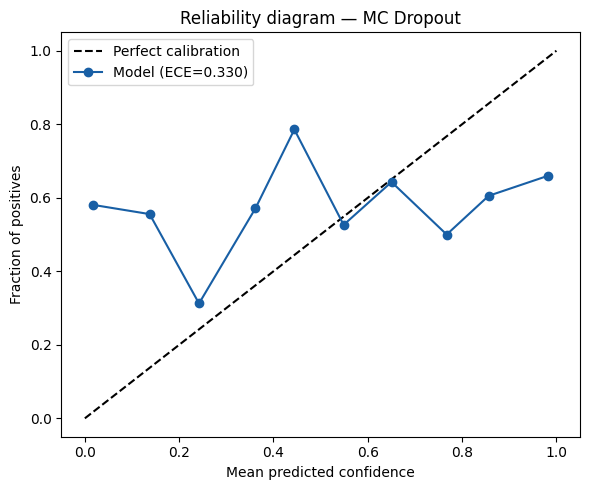

In [17]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def expected_calibration_error(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece  = 0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0: continue
        acc  = labels[mask].mean()
        conf = probs[mask].mean()
        ece += mask.sum() * abs(acc - conf)
    return ece / len(probs)

# Paste expected_calibration_error() and the reliability diagram
# code from previous guide Step 7 — no changes needed.

ece = expected_calibration_error(mean_p, true_labels)
print(f"ECE = {ece:.4f}")

# Also compute: are high-confidence predictions actually more accurate?
conf_mask = mean_p > 0.9   # very confident predictions
if conf_mask.sum() > 0:
    hi_acc = ((mean_p[conf_mask]>0.5)==true_labels[conf_mask]).mean()
    print(f"Accuracy on high-confidence (>0.9) samples: {hi_acc:.3f}")
    print(f"Count: {conf_mask.sum()} / {len(mean_p)} samples")

# Reliability diagram
frac_pos, mean_pred = calibration_curve(true_labels, mean_p, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot([0,1],[0,1],"k--", label="Perfect calibration")
plt.plot(mean_pred, frac_pos, "o-", color="#185FA5", label=f"Model (ECE={ece:.3f})")
plt.xlabel("Mean predicted confidence")
plt.ylabel("Fraction of positives")
plt.title("Reliability diagram — MC Dropout")
plt.legend(); plt.tight_layout()
plt.savefig("reliability_diagram.png", dpi=150)
plt.show()

=== LOW uncertainty ===


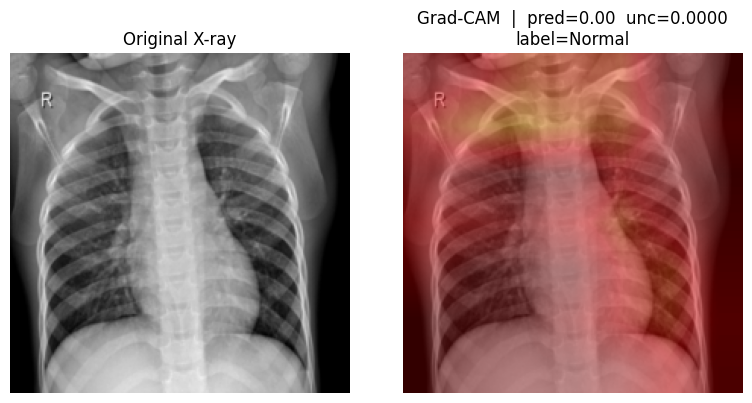

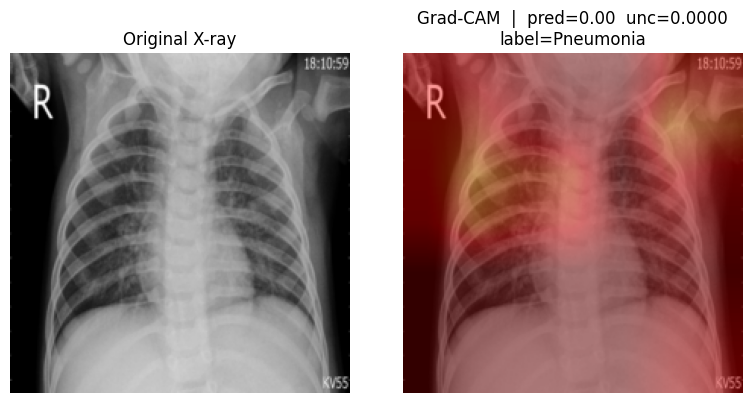

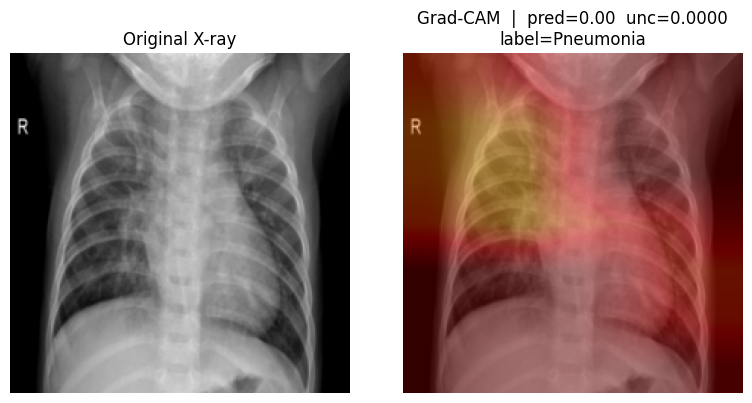

=== HIGH uncertainty ===


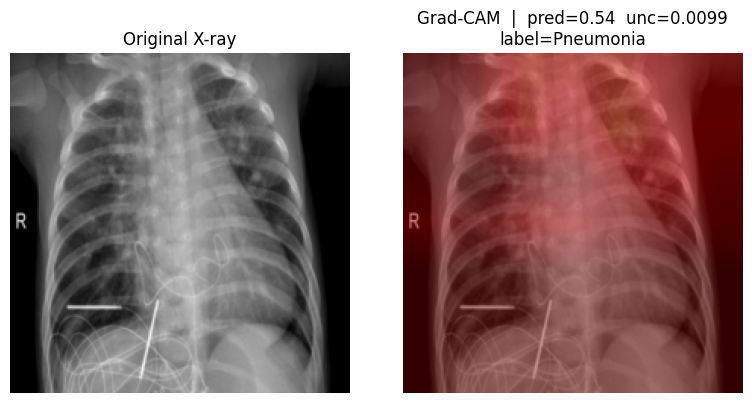

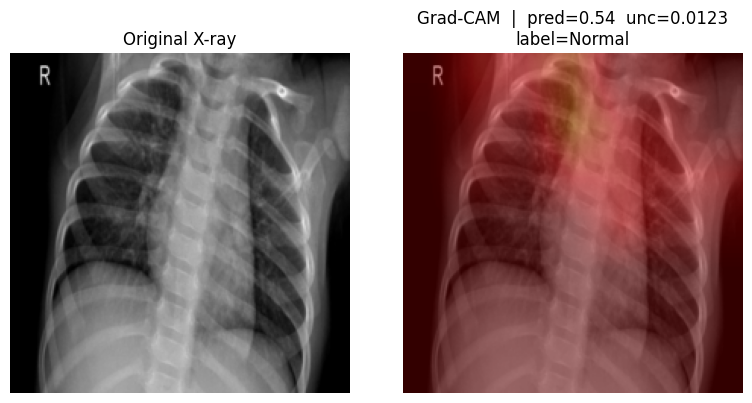

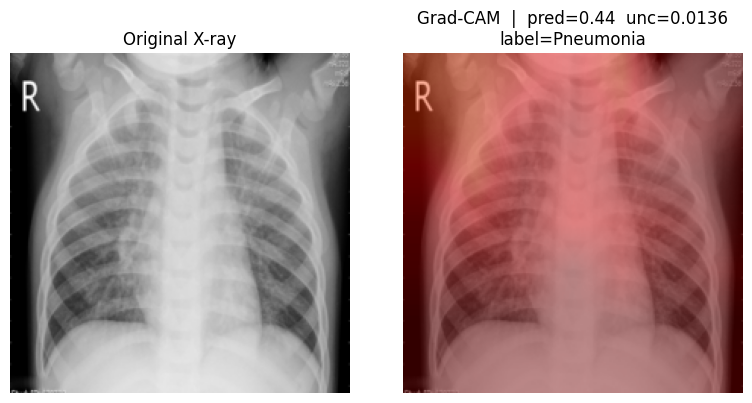

In [19]:
from torchvision import transforms as T
from torchvision.datasets import ImageFolder

display_tf = T.Compose([T.Resize((224,224)), T.ToTensor()])
test_raw   = ImageFolder(
    os.path.join(BASE, "test"), transform=display_tf)

import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(
            lambda m,i,o: setattr(self,'activations',o))
        target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'gradients',go[0]))

    def generate(self, img_tensor, class_idx=0):
        self.model.train()   # keep dropout for consistency
        out = self.model(img_tensor)
        self.model.zero_grad()
        out[0, class_idx].backward()
        w   = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = (w * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam).cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


def show_gradcam(img_tensor, orig_img, label, pred, unc):
    cam  = gcam.generate(img_tensor.unsqueeze(0).to(device))
    cam_r= cv2.resize(cam, (224,224))
    heat = cv2.applyColorMap(
        (cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    orig = np.array(orig_img.resize((224,224)))
    overlay = cv2.addWeighted(orig, 0.6, heat, 0.4, 0)
    fig, axes = plt.subplots(1,2,figsize=(8,4))
    axes[0].imshow(orig, cmap="gray"); axes[0].set_title("Original X-ray")
    axes[1].imshow(overlay)
    axes[1].set_title(
        f"Grad-CAM  |  pred={pred:.2f}  unc={unc:.4f}\nlabel={'Pneumonia' if label else 'Normal'}")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.savefig("gradcam_sample.png", dpi=150); plt.show()




# Target layer: model.features.denseblock4  (same for DenseNet-121)

gcam = GradCAM(model, model.features.denseblock4)

# Show 3 low-uncertainty and 3 high-uncertainty cases
sorted_idx   = np.argsort(var_p)
low_unc_idx  = sorted_idx[:3]
high_unc_idx = sorted_idx[-3:]

import torchvision.transforms.functional as TF

for label_group, idxs in [("LOW uncertainty", low_unc_idx),
                           ("HIGH uncertainty", high_unc_idx)]:
    print(f"=== {label_group} ===")
    for i in idxs:
        img_t,  lbl = test_ds[i]
        img_raw, _  = test_raw[i]
        # Convert raw tensor to PIL for overlay
        from torchvision.transforms.functional import to_pil_image
        show_gradcam(img_t, to_pil_image(img_raw), lbl, mean_p[i], var_p[i])

In [20]:
from sklearn.metrics import (roc_auc_score, f1_score,
    classification_report, confusion_matrix)

preds_bin = (mean_p > 0.5).astype(int)
auc = roc_auc_score(true_labels, mean_p)
f1  = f1_score(true_labels, preds_bin)

print(f"AUC-ROC   : {auc:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ECE       : {ece:.4f}")
print(f"Mean uncertainty (all)       : {var_p.mean():.4f}")
print(f"Mean uncertainty (correct)   : {var_p[preds_bin==true_labels].mean():.4f}")
print(f"Mean uncertainty (incorrect) : {var_p[preds_bin!=true_labels].mean():.4f}")
print()
print(classification_report(true_labels, preds_bin,
    target_names=["Normal","Pneumonia"]))

AUC-ROC   : 0.5350
F1 Score  : 0.7031
ECE       : 0.3304
Mean uncertainty (all)       : 0.0012
Mean uncertainty (correct)   : 0.0010
Mean uncertainty (incorrect) : 0.0014

              precision    recall  f1-score   support

      Normal       0.43      0.29      0.34       234
   Pneumonia       0.64      0.77      0.70       390

    accuracy                           0.59       624
   macro avg       0.54      0.53      0.52       624
weighted avg       0.56      0.59      0.57       624

